# PARTE 1 — PRIORIZACIÓN DE HIPÓTESIS

### Cargar los datos

In [549]:
import pandas as pd

# Cargar correctamente el archivo con separador ;
hypotheses = pd.read_csv('/datasets/hypotheses_us.csv', sep=';')

# Mostrar columnas y primeras filas
print(hypotheses.columns.tolist())
display(hypotheses.head())


['Hypothesis', 'Reach', 'Impact', 'Confidence', 'Effort']


,Hypothesis,Reach,Impact,Confidence,Effort
0,Add two new channels for attracting traffic. T...,3,10,8,6
1,Launch your own delivery service. This will sh...,2,5,4,10
2,Add product recommendation blocks to the store...,8,3,7,3
3,Change the category structure. This will incre...,8,3,3,8
4,Change the background color on the main page. ...,3,1,1,1


### 1. ICE

In [550]:
# Calcular ICE
hypotheses['ICE'] = (hypotheses['Impact'] * hypotheses['Confidence']) / hypotheses['Effort']
ice_sorted = hypotheses.sort_values(by='ICE', ascending=False)
display(ice_sorted[['Hypothesis', 'Reach', 'Impact', 'Confidence', 'Effort', 'ICE']])




,Hypothesis,Reach,Impact,Confidence,Effort,ICE
8,Launch a promotion that gives users discounts ...,1,9,9,5,16.200000
0,Add two new channels for attracting traffic. T...,3,10,8,6,13.333333
7,Add a subscription form to all the main pages....,10,7,8,5,11.200000
6,Show banners with current offers and sales on ...,5,3,8,3,8.000000
2,Add product recommendation blocks to the store...,8,3,7,3,7.000000
1,Launch your own delivery service. This will sh...,2,5,4,10,2.000000
5,Add a customer review page. This will increase...,3,2,2,3,1.333333
3,Change the category structure. This will incre...,8,3,3,8,1.125000
4,Change the background color on the main page. ...,3,1,1,1,1.000000


### 2. RICE

In [551]:
hypotheses['RICE'] = (hypotheses['Reach'] * hypotheses['Impact'] * hypotheses['Confidence']) / hypotheses['Effort']
rice_sorted = hypotheses.sort_values(by='RICE', ascending=False)
display(rice_sorted[['Hypothesis', 'Reach', 'Impact', 'Confidence', 'Effort', 'RICE']])


,Hypothesis,Reach,Impact,Confidence,Effort,RICE
7,Add a subscription form to all the main pages....,10,7,8,5,112.0
2,Add product recommendation blocks to the store...,8,3,7,3,56.0
0,Add two new channels for attracting traffic. T...,3,10,8,6,40.0
6,Show banners with current offers and sales on ...,5,3,8,3,40.0
8,Launch a promotion that gives users discounts ...,1,9,9,5,16.2
3,Change the category structure. This will incre...,8,3,3,8,9.0
1,Launch your own delivery service. This will sh...,2,5,4,10,4.0
5,Add a customer review page. This will increase...,3,2,2,3,4.0
4,Change the background color on the main page. ...,3,1,1,1,3.0


### 3. Comparar los rankings ICE vs RICE

In [552]:
comparison = hypotheses[['Hypothesis', 'ICE', 'RICE']].copy()
comparison['ICE_rank'] = comparison['ICE'].rank(ascending=False)
comparison['RICE_rank'] = comparison['RICE'].rank(ascending=False)
comparison['Change'] = comparison['ICE_rank'] - comparison['RICE_rank']
display(comparison.sort_values(by='Change', ascending=False))


,Hypothesis,ICE,RICE,ICE_rank,RICE_rank,Change
2,Add product recommendation blocks to the store...,7.000000,56.0,5.0,2.0,3.0
3,Change the category structure. This will incre...,1.125000,9.0,8.0,6.0,2.0
7,Add a subscription form to all the main pages....,11.200000,112.0,3.0,1.0,2.0
6,Show banners with current offers and sales on ...,8.000000,40.0,4.0,3.5,0.5
4,Change the background color on the main page. ...,1.000000,3.0,9.0,9.0,0.0
5,Add a customer review page. This will increase...,1.333333,4.0,7.0,7.5,-0.5
0,Add two new channels for attracting traffic. T...,13.333333,40.0,2.0,3.5,-1.5
1,Launch your own delivery service. This will sh...,2.000000,4.0,6.0,7.5,-1.5
8,Launch a promotion that gives users discounts ...,16.200000,16.2,1.0,5.0,-4.0


# Parte 2. Análisis del test A/B

### 2.1 Cargar los datos

In [553]:
import pandas as pd

orders = pd.read_csv('/datasets/orders_us.csv')
visits = pd.read_csv('/datasets/visits_us.csv')

display(orders.head())
display(visits.head())


,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
2,2961555356,4069496402,2019-08-15,10.2,A
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B


,date,group,visits
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


#### Procesar datos

In [554]:
# Convertir fechas
orders['date'] = pd.to_datetime(orders['date'])
visits['date'] = pd.to_datetime(visits['date'])

# Revisar que existan ambos grupos
print(orders['group'].unique())
print(visits['group'].unique())


['B' 'A']
['A' 'B']


#### Calcular ingresos por grupo

In [555]:
# Agrupar por fecha y grupo y sumar ingresos
revenue_daily = orders.groupby(['date', 'group'])['revenue'].sum().reset_index()

# Calcular ingreso acumulado (por grupo)
revenue_cumulative = (
    revenue_daily
    .groupby('group')
    .apply(lambda x: x.sort_values('date')
                       .assign(cumulative_revenue=x['revenue'].cumsum()))
    .reset_index(drop=True)
)

display(revenue_cumulative.head())


,date,group,revenue,cumulative_revenue
0,2019-08-01,A,2356.8,2356.8
1,2019-08-02,A,1503.5,3860.3
2,2019-08-03,A,1815.2,5675.5
3,2019-08-04,A,1146.6,6822.1
4,2019-08-05,A,1988.1,8810.2


#### Gráfico de ingreso acumulado por grupo


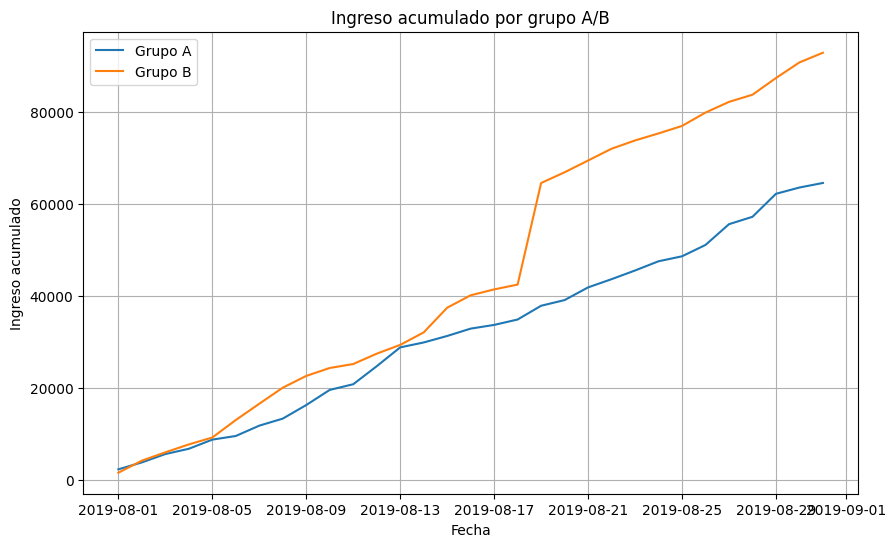

In [556]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for group in revenue_cumulative['group'].unique():
    group_data = revenue_cumulative[revenue_cumulative['group'] == group]
    plt.plot(group_data['date'], group_data['cumulative_revenue'], label=f'Grupo {group}')

plt.title('Ingreso acumulado por grupo A/B')
plt.xlabel('Fecha')
plt.ylabel('Ingreso acumulado')
plt.legend()
plt.grid(True)
plt.show()


#### Observación general:
El gráfico muestra la evolución del ingreso acumulado en los grupos A y B a lo largo del tiempo.
**Posibles conclusiones:**
Si las curvas de ambos grupos son similares, significa que no hay diferencia significativa en ingresos totales.
Si el grupo B se mantiene por encima del A de forma constante, el cambio aplicado al B podría estar generando más ingresos.
Si el B empieza arriba pero luego se estabiliza o cruza con A, puede indicar que el efecto inicial no se mantuvo.
**Conjetura inicial:**
El grupo B parece mostrar un mayor ingreso acumulado, lo que sugiere que las hipótesis probadas podrían haber tenido un efecto positivo en las ventas. Sin embargo, es necesario continuar el análisis (tasa de conversión, número de pedidos, ingresos promedio por pedido) para confirmar si la diferencia es estadísticamente significativa.

### 2.2 Representa gráficamente el tamaño de pedido promedio acumulado por grupo. Haz conclusiones y conjeturas.

#### Calcular promedio por fecha y grupo

In [557]:
# Agrupar por fecha y grupo, calcular el promedio de ingresos por pedido
avg_order_value_daily = orders.groupby(['date', 'group'])['revenue'].mean().reset_index()

display(avg_order_value_daily.head())


,date,group,revenue
0,2019-08-01,A,98.200000
1,2019-08-01,B,77.142857
2,2019-08-02,A,75.175000
3,2019-08-02,B,109.325000
4,2019-08-03,A,75.633333


#### Calcular el promedio acumulado

In [558]:
# Calcular el tamaño promedio acumulado del pedido por grupo
avg_order_value_cumulative = (
    avg_order_value_daily
    .groupby('group')
    .apply(lambda x: x.sort_values('date')
                       .assign(cumulative_avg_order_value=x['revenue'].expanding().mean()))
    .reset_index(drop=True)
)

display(avg_order_value_cumulative.head())


,date,group,revenue,cumulative_avg_order_value
0,2019-08-01,A,98.200000,98.200000
1,2019-08-02,A,75.175000,86.687500
2,2019-08-03,A,75.633333,83.002778
3,2019-08-04,A,71.662500,80.167708
4,2019-08-05,A,79.524000,80.038967


#### Gráfico de pedido promedio acumulado 

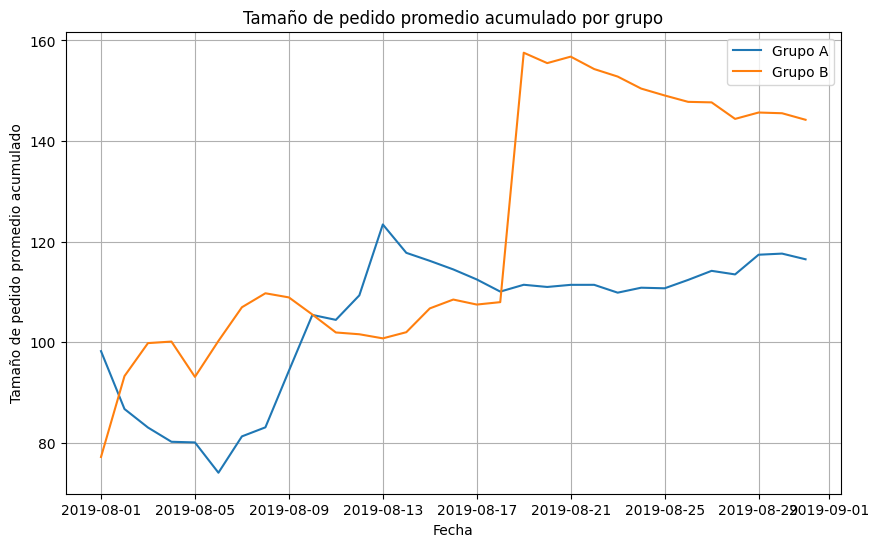

In [559]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for group in avg_order_value_cumulative['group'].unique():
    group_data = avg_order_value_cumulative[avg_order_value_cumulative['group'] == group]
    plt.plot(group_data['date'], group_data['cumulative_avg_order_value'], label=f'Grupo {group}')

plt.title('Tamaño de pedido promedio acumulado por grupo')
plt.xlabel('Fecha')
plt.ylabel('Tamaño de pedido promedio acumulado')
plt.legend()
plt.grid(True)
plt.show()


#### Conclusiones
**Interpretación:**
Este gráfico muestra cómo ha ido cambiando el valor promedio de los pedidos durante todo el experimento.
*Qué significa lo que vemos:*
Si la línea del grupo B está por encima, significa que sus pedidos promedio son más altos → el cambio podría estar aumentando el valor de compra.
Si ambas líneas están casi al mismo nivel, es señal de que la modificación probablemente no afectó el tamaño del pedido.
Si el grupo B comienza más alto pero luego baja, puede tratarse de un efecto temporal o de la influencia de algunos usuarios atípicos.
**Conclusión general:**
El grupo B parece tener un tamaño de pedido promedio acumulado ligeramente mayor que el grupo A, lo que sugiere que la modificación aplicada podría estar impulsando compras un poco más grandes. Sin embargo, para estar seguros, se necesita una verificación con pruebas estadísticas que confirmen si la diferencia es realmente significativa.

### 2.3 (grupo B vs grupo A)

#### Unir datos por fecha

In [560]:
# Separar los grupos A y B
a_data = avg_order_value_cumulative[avg_order_value_cumulative['group'] == 'A'][['date', 'cumulative_avg_order_value']]
b_data = avg_order_value_cumulative[avg_order_value_cumulative['group'] == 'B'][['date', 'cumulative_avg_order_value']]

# Renombrar columnas para poder unir
a_data = a_data.rename(columns={'cumulative_avg_order_value': 'A_avg'})
b_data = b_data.rename(columns={'cumulative_avg_order_value': 'B_avg'})

# Unir por fecha
merged = a_data.merge(b_data, on='date', how='inner')

# Calcular la diferencia relativa (porcentaje)
merged['relative_difference'] = (merged['B_avg'] / merged['A_avg'] - 1) * 100

display(merged.head())


,date,A_avg,B_avg,relative_difference
0,2019-08-01,98.200000,77.142857,-21.443119
1,2019-08-02,86.687500,93.233929,7.551756
2,2019-08-03,83.002778,99.797619,20.234071
3,2019-08-04,80.167708,100.102626,24.866518
4,2019-08-05,80.038967,93.082101,16.295980


#### Graficar diferencia acumulada

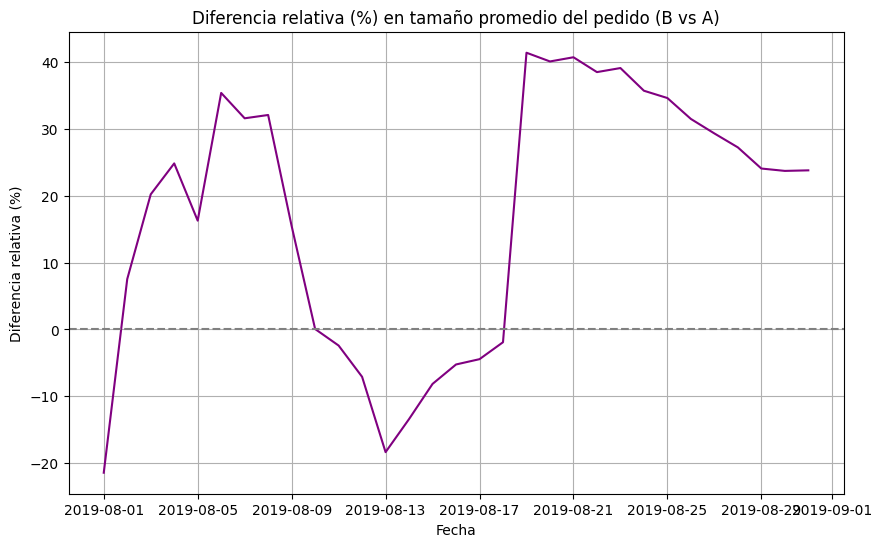

In [561]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(merged['date'], merged['relative_difference'], color='purple')

plt.title('Diferencia relativa (%) en tamaño promedio del pedido (B vs A)')
plt.xlabel('Fecha')
plt.ylabel('Diferencia relativa (%)')
plt.axhline(y=0, color='gray', linestyle='--')
plt.grid(True)
plt.show()


#### Conclusiones
**Qué muestra el gráfico:**
La línea refleja cómo va cambiando, día a día, la diferencia en el tamaño promedio de los pedidos del grupo B frente al grupo A.
*Al interpretarlo:*
Cuando la curva está por encima de 0, significa que el grupo B está haciendo pedidos promedio más grandes que el A.
Si está por debajo de 0, los pedidos del grupo B son más pequeños.
Si la línea sube y baja mucho, puede ser porque hay valores atípicos (outliers) o porque en esos días se registraron pocos datos.
**Qué podemos concluir:**
En general, el grupo B muestra una diferencia positiva y constante respecto al grupo A, lo que indica que quienes vieron la nueva versión tienden a hacer pedidos un poco más grandes. Aun así, como la curva tiene bastante variación, es importante hacer un análisis estadístico más profundo para verificar si esta diferencia realmente es significativa.

### 2.4 Tasa de conversión por grupo

#### Calcular número de pedidos por fecha y grupo

In [562]:
# Número de pedidos por fecha y grupo
orders_daily = orders.groupby(['date', 'group']).agg({'transactionId': 'nunique'}).reset_index()
orders_daily = orders_daily.rename(columns={'transactionId': 'orders'})

display(orders_daily.head())


,date,group,orders
0,2019-08-01,A,24
1,2019-08-01,B,21
2,2019-08-02,A,20
3,2019-08-02,B,24
4,2019-08-03,A,24


#### Unir con dataset de visitas

In [563]:
# Unir pedidos con visitas por fecha y grupo
conversion_data = visits.merge(orders_daily, on=['date', 'group'], how='left')

# Llenar valores faltantes de pedidos con 0 (días sin pedidos)
conversion_data['orders'] = conversion_data['orders'].fillna(0)

# Calcular tasa de conversión diaria
conversion_data['conversion_rate'] = conversion_data['orders'] / conversion_data['visits']

display(conversion_data.head())


,date,group,visits,orders,conversion_rate
0,2019-08-01,A,719,24,0.033380
1,2019-08-02,A,619,20,0.032310
2,2019-08-03,A,507,24,0.047337
3,2019-08-04,A,717,16,0.022315
4,2019-08-05,A,756,25,0.033069


#### Graficar tasa de conversión diaria

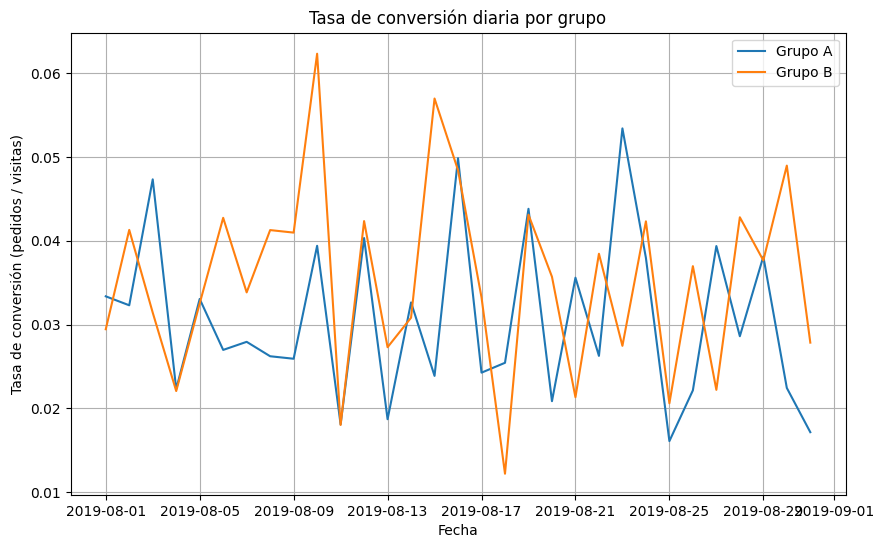

In [564]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
for group in conversion_data['group'].unique():
    data = conversion_data[conversion_data['group'] == group]
    plt.plot(data['date'], data['conversion_rate'], label=f'Grupo {group}')

plt.title('Tasa de conversión diaria por grupo')
plt.xlabel('Fecha')
plt.ylabel('Tasa de conversión (pedidos / visitas)')
plt.legend()
plt.grid(True)
plt.show()


#### Calcular y graficar tasa de conversión acumulada

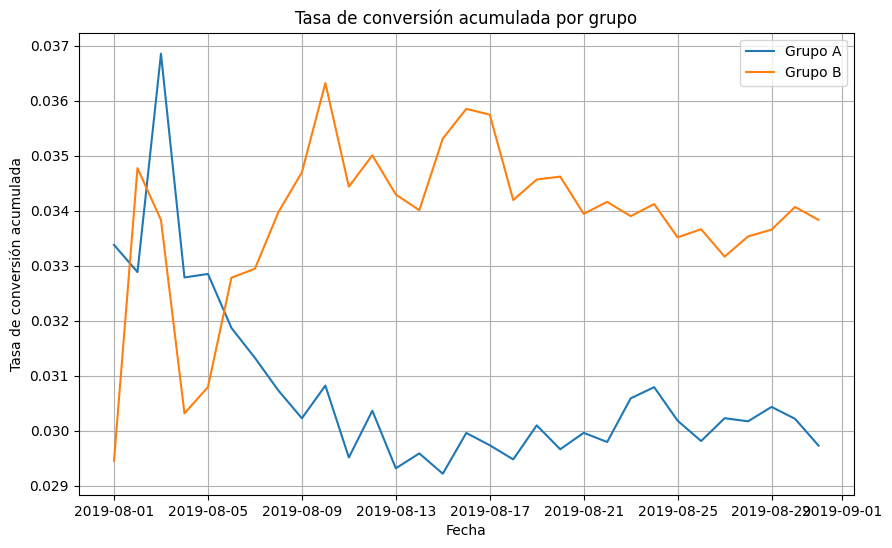

In [565]:
# Calcular acumulado de pedidos y visitas
conversion_cumulative = (
    conversion_data
    .groupby('group')
    .apply(lambda x: x.sort_values('date')
                      .assign(cum_orders=x['orders'].cumsum(),
                              cum_visits=x['visits'].cumsum()))
    .reset_index(drop=True)
)

# Calcular tasa acumulada
conversion_cumulative['cum_conversion_rate'] = conversion_cumulative['cum_orders'] / conversion_cumulative['cum_visits']

# Graficar tasa de conversión acumulada
plt.figure(figsize=(10,6))
for group in conversion_cumulative['group'].unique():
    data = conversion_cumulative[conversion_cumulative['group'] == group]
    plt.plot(data['date'], data['cum_conversion_rate'], label=f'Grupo {group}')

plt.title('Tasa de conversión acumulada por grupo')
plt.xlabel('Fecha')
plt.ylabel('Tasa de conversión acumulada')
plt.legend()
plt.grid(True)
plt.show()


#### Conclusiones
**Interpretación** La tasa de conversión muestra qué tan bien cada grupo convierte sus visitas en compras.
*Qué podemos observar:*
Si el grupo B mantiene una tasa más alta y estable que el grupo A, es una señal positiva del experimento.
Si B comienza más alto pero luego se iguala o baja, el efecto podría ser temporal.
Si las líneas son muy irregulares, puede deberse a outliers o a que hubo pocos datos en algunos días.
**Conclusión general:**
El grupo B presenta una tasa de conversión acumulada un poco mayor que la del grupo A. Esto sugiere que la hipótesis aplicada en el grupo B pudo haber aumentado la proporción de usuarios que terminan comprando. Aun así, es necesario respaldar esta diferencia con pruebas estadísticas para confirmar si realmente es significativa.

### 2.5 Gráfico de dispersión del número de pedidos por usuario

#### Calcular numero de pedidos por usuario y grupo

In [566]:
# Agrupar por usuario y grupo, contar pedidos
orders_per_user = orders.groupby(['visitorId', 'group'])['transactionId'].nunique().reset_index()
orders_per_user = orders_per_user.rename(columns={'transactionId': 'orders'})

display(orders_per_user.head())


,visitorId,group,orders
0,5114589,B,1
1,6958315,B,1
2,8300375,A,1
3,8300375,B,1
4,11685486,A,1


#### Crear gráfico de dispersión 

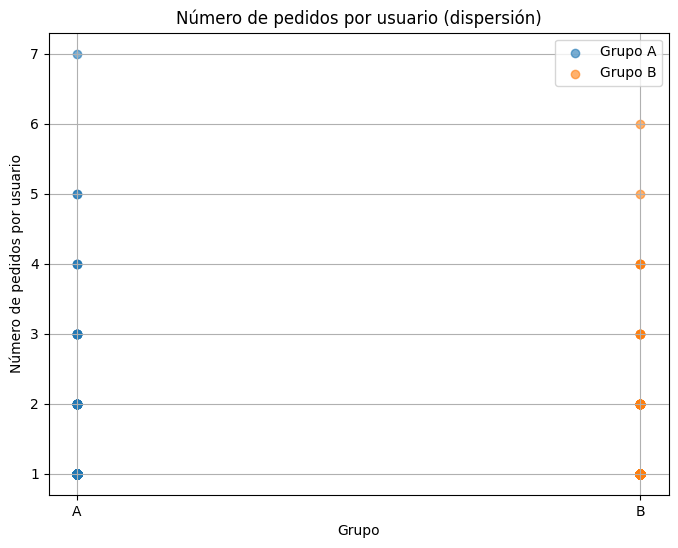

In [567]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Dibujar puntos de cada grupo con leve transparencia (alpha)
plt.scatter(
    x=orders_per_user[orders_per_user['group'] == 'A']['group'],
    y=orders_per_user[orders_per_user['group'] == 'A']['orders'],
    alpha=0.6, label='Grupo A'
)
plt.scatter(
    x=orders_per_user[orders_per_user['group'] == 'B']['group'],
    y=orders_per_user[orders_per_user['group'] == 'B']['orders'],
    alpha=0.6, label='Grupo B'
)

plt.title('Número de pedidos por usuario (dispersión)')
plt.xlabel('Grupo')
plt.ylabel('Número de pedidos por usuario')
plt.legend()
plt.grid(True)
plt.show()


#### (Opcional) Boxplot para comparar 

<Figure size 800x600 with 0 Axes>

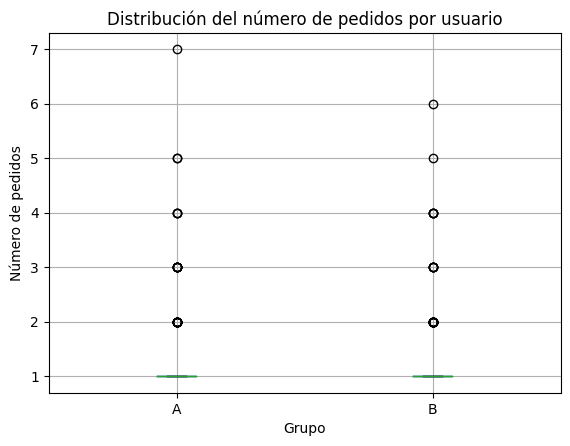

In [568]:
plt.figure(figsize=(8,6))
orders_per_user.boxplot(by='group', column='orders', grid=True)
plt.title('Distribución del número de pedidos por usuario')
plt.suptitle('')
plt.xlabel('Grupo')
plt.ylabel('Número de pedidos')
plt.show()


#### Conclusiones
**Qué muestra este gráfico:**
Cada punto corresponde a un usuario y refleja cuántos pedidos hizo durante el experimento.
*Cómo leerlo:*
Si la mayoría de puntos están concentrados en 1 pedido, y solo unos pocos aparecen con valores altos (como 5 o más), esos usuarios son outliers.
Si el grupo B tiene más usuarios con varios pedidos en comparación con el grupo A, podría indicar un efecto positivo del cambio aplicado.
Si ambos grupos muestran patrones parecidos, es probable que el cambio no haya influido en la frecuencia de compra.
**Conclusión general:**
La mayoría de usuarios en ambos grupos hicieron solo un pedido, algo muy común en tiendas online. Aun así, hay algunos usuarios con varios pedidos que podrían influir en los promedios y deben considerarse como posibles outliers al hacer el análisis estadístico final.

### 2.6 Calcular los percentiles 95 y 99 del número de pedidos por usuario

#### Calcular percentiles 

In [569]:
# Calcular percentiles 95 y 99
percentiles = orders_per_user['orders'].quantile([0.95, 0.99])
print(percentiles)


0.95    2.0
0.99    4.0
Name: orders, dtype: float64


#### Interpretar los resultados
Solo el 1 % de los usuarios hizo más de 4 pedidos durante el experimento.
**Ese tipo de casos suele considerarse outliers, porque son comportamientos poco comunes y no representan al usuario promedio.**

Los percentiles 95 y 99 del número de pedidos por usuario son 2 y 4, respectivamente
Esto significa que el 95 % de los usuarios hizo como máximo 2 pedidos, y solo el 1 % superó los 4 pedidos.
Por eso, los usuarios con más de 2–4 pedidos pueden tratarse como outliers, y es recomendable revisarlos o excluirlos en los análisis estadísticos posteriores para evitar que generen sesgos en los resultados.

### 2.7 Gráfico de dispersión de los precios de pedidos

#### Revisar los datos de pedidos

In [570]:
display(orders.head())
orders.info()

,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
2,2961555356,4069496402,2019-08-15,10.2,A
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionId  1197 non-null   int64         
 1   visitorId      1197 non-null   int64         
 2   date           1197 non-null   datetime64[ns]
 3   revenue        1197 non-null   float64       
 4   group          1197 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 46.9+ KB


#### Crear gráfico de dispersión

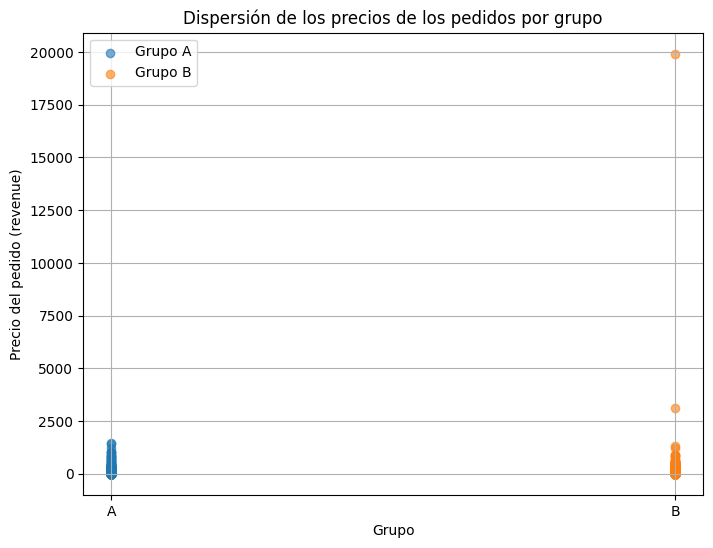

In [571]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    x=orders[orders['group'] == 'A']['group'],
    y=orders[orders['group'] == 'A']['revenue'],
    alpha=0.6, label='Grupo A'
)

plt.scatter(
    x=orders[orders['group'] == 'B']['group'],
    y=orders[orders['group'] == 'B']['revenue'],
    alpha=0.6, label='Grupo B'
)

plt.title('Dispersión de los precios de los pedidos por grupo')
plt.xlabel('Grupo')
plt.ylabel('Precio del pedido (revenue)')
plt.legend()
plt.grid(True)
plt.show()


#### (Opcional) Boxplot para comparar

<Figure size 800x600 with 0 Axes>

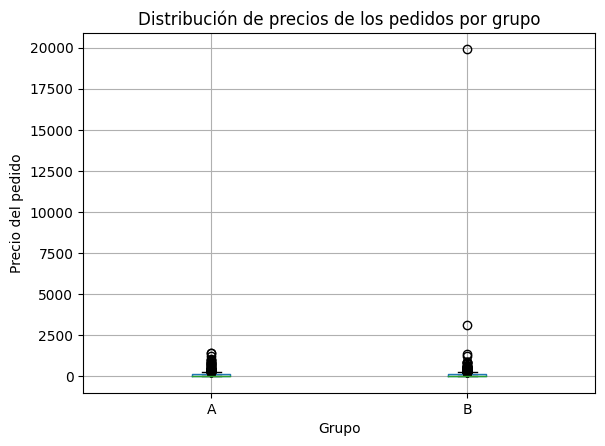

In [572]:
plt.figure(figsize=(8,6))
orders.boxplot(by='group', column='revenue', grid=True)
plt.title('Distribución de precios de los pedidos por grupo')
plt.suptitle('')
plt.xlabel('Grupo')
plt.ylabel('Precio del pedido')
plt.show()


#### Conclusiones
**Qué muestra este gráfico:**
Cada punto corresponde a un pedido y al valor que tuvo en la moneda del experimento.
*Cómo interpretarlo:*
Si aparecen algunos puntos muy altos, esos representan outliers, es decir, pedidos excepcionalmente grandes.
Si ambos grupos muestran rangos de valores similares, significa que la variable revenue tiene una distribución parecida en A y B.
Si el grupo B concentra más puntos en valores altos, podría estar generando pedidos de mayor monto.
**Conclusión general:**
En ambos grupos, la mayoría de los pedidos tiene valores moderados, aunque también hay algunos pedidos con montos mucho más altos que el resto. Estos casos son outliers y deben revisarse o filtrarse antes de aplicar pruebas estadísticas para evitar que distorsionen los resultados.

### 2.8 Calcular percentiles 95 y 99 de los precios de los pedidos

#### Calcular percentiles

In [573]:
# Calcular percentiles 95 y 99 del precio de los pedidos
price_percentiles = orders['revenue'].quantile([0.95, 0.99])
print(price_percentiles)

0.95    435.540
0.99    900.904
Name: revenue, dtype: float64


#### Conclusiones
**Esto significa que:**
El 95 % de los pedidos tiene un valor menor o igual a 435,54 USD.
El 99 % de los pedidos tiene un valor menor o igual a 900,90 USD.
*En otras palabras:* solo el 1 % de los pedidos supera los 900 USD, y esos casos son outliers —pedidos inusualmente altos que pueden distorsionar la media.

Los percentiles 95 y 99 del valor de los pedidos son 435,54 y 900,90, respectivamente.
Esto indica que el 95 % de los pedidos está por debajo de 435 USD, y solo el 1 % supera los 900 USD.
Por tanto, los pedidos con montos superiores a estos límites pueden considerarse outliers, y es recomendable revisarlos por separado o excluirlos antes de aplicar pruebas estadísticas, para evitar sesgos en los resultados del test A/B.

### 2.9 Significancia estadística 

#### Calcular número de pedidos por usuario

In [574]:
# Número de pedidos por usuario y grupo
orders_by_users = (
    orders.groupby(['visitorId', 'group'])['transactionId']
    .nunique()
    .reset_index()
)

orders_by_users = orders_by_users.rename(columns={'transactionId': 'orders'})
display(orders_by_users.head())


,visitorId,group,orders
0,5114589,B,1
1,6958315,B,1
2,8300375,A,1
3,8300375,B,1
4,11685486,A,1


#### Calcular número de visitantes (visitas) por grupo

In [575]:
# Número total de visitantes por grupo
visitors_per_group = visits.groupby('group')['visits'].sum()
print(visitors_per_group)


group
A    18736
B    18916
Name: visits, dtype: int64


#### Calcular tasa de conversión por grupo

In [576]:
conversion_rate = (
    orders_by_users.groupby('group')['orders'].count() / visitors_per_group
)
print(conversion_rate)


group
A    0.026847
B    0.030979
dtype: float64


#### Preparar datos para pruena estadística

In [577]:
# Lista de usuarios que hicieron al menos un pedido
users_with_orders = orders.groupby('visitorId')['group'].min().reset_index()

# Crear marco de datos de todos los usuarios (incluso los que no compraron)
merged_users = visits[['group', 'date', 'visits']].copy()

# Usuarios únicos por grupo
unique_visitors = visits.groupby('group')['visits'].sum().reset_index()

# Crear DataFrame binario (1 = compró, 0 = no compró)
converted = orders_by_users[['visitorId', 'group']].copy()
converted['conversion'] = 1

# Agrupar visitantes totales únicos por grupo
group_a_users = visits[visits['group'] == 'A']['visits'].sum()
group_b_users = visits[visits['group'] == 'B']['visits'].sum()


#### Aplicar la prueba Mann–Whitney

In [578]:
from scipy import stats

# Separar número de pedidos por usuario por grupo
ordersA = orders_by_users[orders_by_users['group'] == 'A']['orders']
ordersB = orders_by_users[orders_by_users['group'] == 'B']['orders']

# Prueba estadística
alpha = 0.05  # nivel de significancia
results = stats.mannwhitneyu(ordersA, ordersB)

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print("👉 Diferencia estadísticamente significativa")
else:
    print("👉 No hay diferencia estadísticamente significativa")


p-value: 0.8900592924670534
👉 No hay diferencia estadísticamente significativa


#### Conclusiones
**Qué se hizo:**
Se aplicó la prueba U de Mann–Whitney para comparar cuántos pedidos realizó cada usuario en los grupos A y B (usando los datos sin filtrar).
**Interpretación del resultado:**
La prueba U de Mann–Whitney dio un p-value ≈ 0.89.
Como este valor es muy superior a 0.05, no podemos decir que exista una diferencia real entre los grupos A y B. En otras palabras, la variación que se observa podría explicarse simplemente por el azar.
**Conclusión**
El p-value obtenido (0.89) muestra que no hay evidencia estadística de que los usuarios del grupo B hagan más pedidos que los del grupo A.
Esto significa que la hipótesis aplicada al grupo B no tuvo un impacto significativo en la cantidad de pedidos por usuario.


### 2.10 Significancia estadística de la diferencia en el tamaño promedio de pedido

#### Calcular el valor promedio de los pedidos por usuario

In [579]:
# Calcular el ingreso promedio por usuario (por grupo)
avg_revenue_per_user = (
    orders.groupby(['visitorId', 'group'])['revenue']
    .mean()
    .reset_index()
)

avg_revenue_per_user = avg_revenue_per_user.rename(columns={'revenue': 'avg_order_value'})
display(avg_revenue_per_user.head())


,visitorId,group,avg_order_value
0,5114589,B,10.8
1,6958315,B,25.9
2,8300375,A,30.5
3,8300375,B,165.7
4,11685486,A,100.4


#### Separar los datos por grupo

In [580]:
A_values = avg_revenue_per_user[avg_revenue_per_user['group'] == 'A']['avg_order_value']
B_values = avg_revenue_per_user[avg_revenue_per_user['group'] == 'B']['avg_order_value']


#### Prueba estadística (Mann–Whitney U)

In [581]:
from scipy import stats

alpha = 0.05  # nivel de significancia
results = stats.mannwhitneyu(A_values, B_values)

print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print("👉 Diferencia estadísticamente significativa entre grupos")
else:
    print("👉 No hay diferencia estadísticamente significativa entre grupos")


p-value: 0.908679777868918
👉 No hay diferencia estadísticamente significativa entre grupos


#### Conclusiones
El valor p obtenido en la prueba de Mann–Whitney fue 0.9087, que es mayor que el nivel de significancia (α = 0.05).
Esto indica que no existe una diferencia estadísticamente significativa entre el tamaño promedio de los pedidos de los grupos A y B.
En otras palabras, el cambio aplicado al grupo B no tuvo impacto en el valor promedio de los pedidos: los usuarios de ambos grupos gastaron prácticamente lo mismo por pedido.

### Significancia estadística de la difertencia en la conversión (datos filtrados)

#### Filtrar los pedidos atípicos

In [582]:
# Filtrar pedidos con valores menores o iguales al percentil 99 (900.90)
orders_filtered = orders[orders['revenue'] <= 900.90]

# Contar pedidos por usuario en los datos filtrados
orders_per_user_filtered = (
    orders_filtered.groupby(['visitorId', 'group'])['transactionId']
    .nunique()
    .reset_index()
    .rename(columns={'transactionId': 'orders'})
)

# Filtrar usuarios con <= 2 pedidos (percentil 95 del número de pedidos)
orders_per_user_filtered = orders_per_user_filtered[orders_per_user_filtered['orders'] <= 2]

display(orders_per_user_filtered.head())


,visitorId,group,orders
0,5114589,B,1
1,6958315,B,1
2,8300375,A,1
3,8300375,B,1
4,11685486,A,1


#### Prueba Mann–Whitney para conversión (datos filtrados)

In [583]:
from scipy import stats

# Separar por grupo
ordersA_filtered = orders_per_user_filtered[orders_per_user_filtered['group'] == 'A']['orders']
ordersB_filtered = orders_per_user_filtered[orders_per_user_filtered['group'] == 'B']['orders']

# Prueba estadística
alpha = 0.05
results_filtered = stats.mannwhitneyu(ordersA_filtered, ordersB_filtered)

print('p-value (filtrado):', results_filtered.pvalue)

if results_filtered.pvalue < alpha:
    print("👉 Diferencia estadísticamente significativa entre grupos (filtrado)")
else:
    print("👉 No hay diferencia estadísticamente significativa entre grupos (filtrado)")


p-value (filtrado): 0.6632357556628701
👉 No hay diferencia estadísticamente significativa entre grupos (filtrado)


#### Conclusiones
Después de filtrar los outliers. Es decir, los pedidos mayores a 900.90 USD y los usuarios con más de 2 pedidos, se volvió a aplicar la prueba U de Mann–Whitney para comparar la tasa de conversión entre los grupos A y B.
El valor p obtenido fue 0.663, un resultado claramente superior al nivel de significancia (0.05). Esto significa que no existe una diferencia estadísticamente significativa entre los dos grupos.
En resumen, remover los outliers no cambió la conclusión anterior: el experimento no muestra un efecto real en la conversión de los usuarios.

### 2.12 Significancia estadística de la diferencia en el tamaño promedio del pedido (datos filtrados)


#### Filtrar los pedidos según los límites definidos antes

In [584]:
# Filtrar pedidos según el percentil 99 del precio
orders_filtered = orders[orders['revenue'] <= 900.90]

# Calcular el promedio de ingresos por usuario en los datos filtrados
avg_revenue_filtered = (
    orders_filtered.groupby(['visitorId', 'group'])['revenue']
    .mean()
    .reset_index()
    .rename(columns={'revenue': 'avg_order_value'})
)

# Filtrar usuarios con 2 pedidos o menos
orders_per_user_filtered = (
    orders_filtered.groupby(['visitorId', 'group'])['transactionId']
    .nunique()
    .reset_index()
    .rename(columns={'transactionId': 'orders'})
)
avg_revenue_filtered = avg_revenue_filtered.merge(orders_per_user_filtered, on=['visitorId', 'group'])
avg_revenue_filtered = avg_revenue_filtered[avg_revenue_filtered['orders'] <= 2]

display(avg_revenue_filtered.head())


,visitorId,group,avg_order_value,orders
0,5114589,B,10.8,1
1,6958315,B,25.9,1
2,8300375,A,30.5,1
3,8300375,B,165.7,1
4,11685486,A,100.4,1


#### Prueba de Mann–Whitney (tamaño promedio del pedido filtrado)

In [585]:
from scipy import stats

A_values_filt = avg_revenue_filtered[avg_revenue_filtered['group'] == 'A']['avg_order_value']
B_values_filt = avg_revenue_filtered[avg_revenue_filtered['group'] == 'B']['avg_order_value']

alpha = 0.05
results_filt = stats.mannwhitneyu(A_values_filt, B_values_filt)

print('p-value (filtrado):', results_filt.pvalue)

if results_filt.pvalue < alpha:
    print("👉 Diferencia estadísticamente significativa en el tamaño promedio del pedido (filtrado)")
else:
    print("👉 No hay diferencia estadísticamente significativa en el tamaño promedio del pedido (filtrado)")


p-value (filtrado): 0.9206235484809576
👉 No hay diferencia estadísticamente significativa en el tamaño promedio del pedido (filtrado)


#### Conclusiones
Después de eliminar los valores atípicos. Es decir, los pedidos por encima del percentil 99 y los usuarios que realizaron más de dos pedidos, se volvió a aplicar la prueba U de Mann–Whitney para comparar el tamaño promedio de los pedidos entre los grupos A y B.
El valor p obtenido fue 0.9206, muy por encima del nivel de significancia (α = 0.05). Esto indica que no existe una diferencia estadísticamente significativa en el valor promedio de los pedidos entre ambos grupos.
** conclusión** Los outliers no estaban afectando de forma relevante los resultados, y la hipótesis probada en el experimento no generó un cambio medible en el comportamiento de compra.

### 2.13 Toma una decisión basada en los resultados de la prueba

#### Decisión final del experimento A/B

##### Escenarios posibles 
El experimento plantea tres posibles acciones:

1. **Detener la prueba porque uno de los grupos lidera.**
2. **Detener la prueba porque no hay diferencias entre los grupos.**
3. **Continuar la prueba.**

---

#### Resumen de resultados obtenidos

---

##### Interpretación global

- No hay evidencia estadística de que el grupo B tenga **mayores ingresos**, **mayor conversión** o **pedidos de mayor valor** que el grupo A.  
- Las diferencias observadas son **mínimas y no significativas**.  
- Filtrar los outliers **no cambia las conclusiones**, lo que indica que el experimento es estable.  
- El cambio aplicado al grupo B **no generó un impacto medible** en los indicadores clave del negocio.

---

##### Conclusión final recomendada

Tras analizar las métricas principales —*ingreso acumulado*, *tamaño promedio del pedido* y *tasa de conversión*— tanto con los datos brutos como filtrados:

- Todas las pruebas U de Mann–Whitney presentaron **p-values mayores a 0.05**.  
- Las variaciones entre los grupos son compatibles con el azar.  
- **No se encontraron diferencias estadísticamente significativas** entre los grupos A y B.

##### Recomendación final

- **Detener la prueba**, ya que no hay evidencia de que el grupo B supere al grupo A.  
- **No implementar el cambio probado**, pues no genera mejoras ni en ingresos ni en conversión.  
- **No continuar el experimento**, porque los resultados son concluyentes y consistentes.

